In [25]:
import pandas as pd

df = pd.read_csv("../raw/movies.csv", sep=',')

In [26]:
import pandas as pd
import numpy as np

In [27]:
df.head()

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


In [28]:
df.shape

(4803, 24)

In [29]:
df.isnull().sum()

index                      0
budget                     0
genres                    28
homepage                3091
id                         0
keywords                 412
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
cast                      43
crew                       0
director                  30
dtype: int64

In [30]:
df.columns

Index(['index', 'budget', 'genres', 'homepage', 'id', 'keywords',
       'original_language', 'original_title', 'overview', 'popularity',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title',
       'vote_average', 'vote_count', 'cast', 'crew', 'director'],
      dtype='object')

In [31]:
df.nunique()

index                   4803
budget                   436
genres                  1168
homepage                1691
id                      4803
keywords                4219
original_language         37
original_title          4801
overview                4800
popularity              4802
production_companies    3697
production_countries     469
release_date            3280
revenue                 3297
runtime                  156
spoken_languages         544
status                     3
tagline                 3944
title                   4800
vote_average              71
vote_count              1609
cast                    4741
crew                    4776
director                2349
dtype: int64

In [32]:
df_clean = df[['runtime', 'popularity', 'vote_average']].copy()

In [33]:
df_clean = df_clean.dropna()

In [34]:
df_clean = df_clean[df_clean['runtime'] > 0]

In [35]:
df_clean.describe()

,runtime,popularity,vote_average
count,4766.000000,4766.000000,4766.000000
mean,107.660722,21.656322,6.113366
std,20.749424,31.885180,1.143996
min,14.000000,0.000372,0.000000
25%,94.000000,4.845939,5.600000
50%,104.000000,13.154411,6.200000
75%,118.000000,28.537602,6.800000
max,338.000000,875.581305,10.000000


In [36]:
df_clean = df_clean[df_clean['runtime'] < 240]

In [37]:
df_clean.shape
df_clean.head()

,runtime,popularity,vote_average
0,162.0,150.437577,7.2
1,169.0,139.082615,6.9
2,148.0,107.376788,6.3
3,165.0,112.312950,7.6
4,132.0,43.926995,6.1


In [38]:
df_clean['runtime_category'] = pd.cut(
    df_clean['runtime'],
    bins=[0, 90, 120, 150, 240],
    labels=['Short', 'Standard', 'Long', 'Very Long']
)

In [39]:
df_clean[['runtime', 'popularity', 'vote_average']].corr()

,runtime,popularity,vote_average
runtime,1.000000,0.236139,0.343919
popularity,0.236139,1.000000,0.275891
vote_average,0.343919,0.275891,1.000000


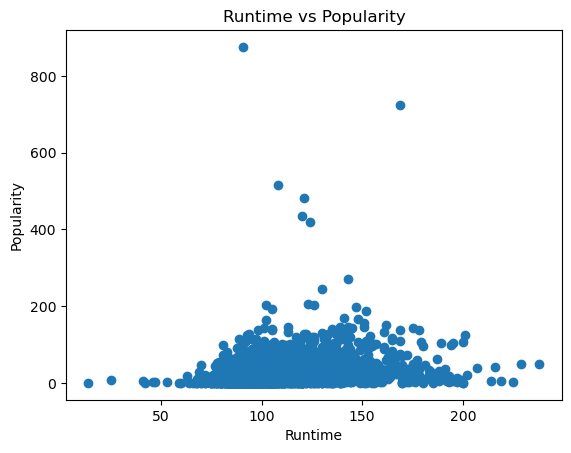

In [40]:
import matplotlib.pyplot as plt

plt.scatter(df_clean['runtime'], df_clean['popularity'])
plt.xlabel('Runtime')
plt.ylabel('Popularity')
plt.title('Runtime vs Popularity')
plt.show()

In [41]:
df = df.drop(columns=['homepage'], errors='ignore')

In [42]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

In [43]:
df['release_year'] = df['release_date'].dt.year

In [44]:
df = df.drop_duplicates()

In [45]:
q_low = df['runtime'].quantile(0.01)
q_high = df['runtime'].quantile(0.99)

df_clean = df[(df['runtime'] >= q_low) & (df['runtime'] <= q_high)]

In [46]:
df_clean['popularity_log'] = np.log1p(df_clean['popularity'])

/var/folders/b7/yg62l3k53kvc1lvmnwswr23m0000gn/T/ipykernel_33724/2583580716.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['popularity_log'] = np.log1p(df_clean['popularity'])


In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_clean[['runtime']])

In [48]:
df_clean = df[['runtime', 'popularity', 'vote_average']].copy()

df_clean = df_clean.dropna()
df_clean = df_clean[df_clean['runtime'] > 0]

# remove outliers
q_low = df_clean['runtime'].quantile(0.01)
q_high = df_clean['runtime'].quantile(0.99)
df_clean = df_clean[(df_clean['runtime'] >= q_low) & (df_clean['runtime'] <= q_high)]

# log transform
df_clean['popularity_log'] = np.log1p(df_clean['popularity'])

In [50]:
df_clean.to_csv('../clean/goncalo_clean.csv', index=False)